In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import FunctionTransformer

In [5]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [6]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\parth\AppData\Local\Temp\ipykernel_4752\1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [8]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [12]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [13]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

Text(0.5, 1.0, 'Age PDF')

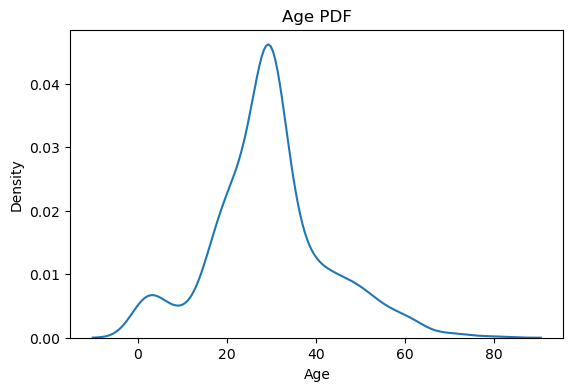

In [15]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.kdeplot(x_train['Age'])
plt.title('Age PDF')

Text(0.5, 1.0, 'Age QQ Plot')

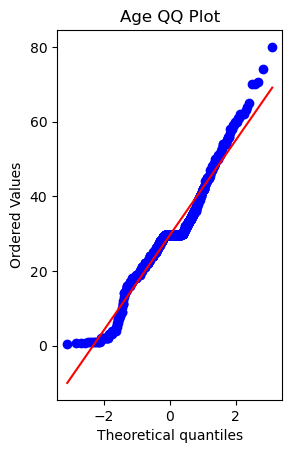

In [17]:
plt.subplot(122)

stats.probplot(
    x_train['Age'],
    dist="norm",
    plot=plt
)

plt.title('Age QQ Plot')

Text(0.5, 1.0, 'Fare PDF')

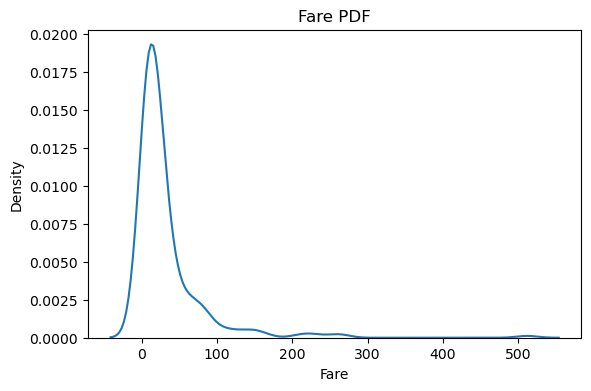

In [18]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.kdeplot(x_train['Fare'])
plt.title('Fare PDF')

Text(0.5, 1.0, 'Fare QQ Plot')

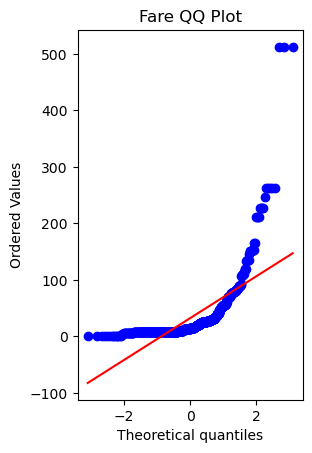

In [19]:
plt.subplot(122)

stats.probplot(
    x_train['Fare'],
    dist="norm",
    plot=plt
)

plt.title('Fare QQ Plot')

In [22]:
ft = FunctionTransformer(np.log1p, validate=True)

In [23]:
x_train_transform = ft.fit_transform(x_train)
x_test_transform = ft.transform(x_test)

In [28]:
x_train_transform

array([[3.83945231, 3.38439026],
       [3.17805383, 2.63905733],
       [3.49650756, 2.18885633],
       ...,
       [3.73766962, 2.71524426],
       [2.7080502 , 4.79579055],
       [3.09104245, 4.36038795]])

In [29]:
x_train_transformed = pd.DataFrame(x_train_transform, columns=x_train.columns)
x_test_transformed = pd.DataFrame(x_test_transform, columns=x_test.columns)


Text(0.5, 1.0, 'Fare QQ Plot')

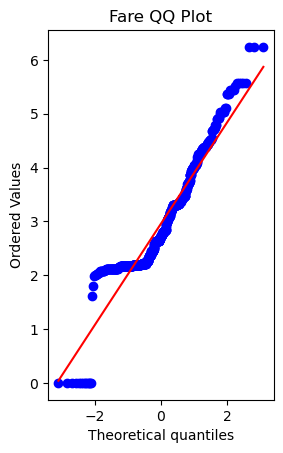

In [31]:
plt.subplot(122)

stats.probplot(
    x_train_transformed['Fare'],
    dist="norm",
    plot=plt
)

plt.title('Fare QQ Plot')

Text(0.5, 1.0, 'Fare QQ Plot')

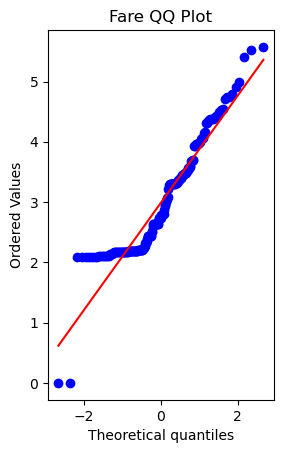

In [32]:
plt.subplot(122)

stats.probplot(
    x_test_transformed['Fare'],
    dist="norm",
    plot=plt
)

plt.title('Fare QQ Plot')